In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [11]:
pure_model_dir = '/remote/gpu01a/pietschke/EoRFlow/output/EoR_flow_logit/pure_z12_10_512_-5_extraNoise'
train_losses_pure = np.load(os.path.join(pure_model_dir, 'train_losses.npy'))
val_losses_pure = np.load(os.path.join(pure_model_dir, 'val_losses.npy'))

In [14]:
outlier_index = np.argmax(train_losses_pure)  # finds the most negative (smallest) value

# Step 2: Compute mean of neighbors
if 0 < outlier_index < len(train_losses_pure) - 1:
    neighbors_mean = (train_losses_pure[outlier_index - 1] + train_losses_pure[outlier_index + 1]) / 2
elif outlier_index == 0:
    neighbors_mean = train_losses_pure[1]  # only right neighbor
elif outlier_index == len(train_losses_pure) - 1:
    neighbors_mean = train_losses_pure[-2]  # only left neighbor

# Step 3: Replace outlier
train_losses_pure[outlier_index] = neighbors_mean

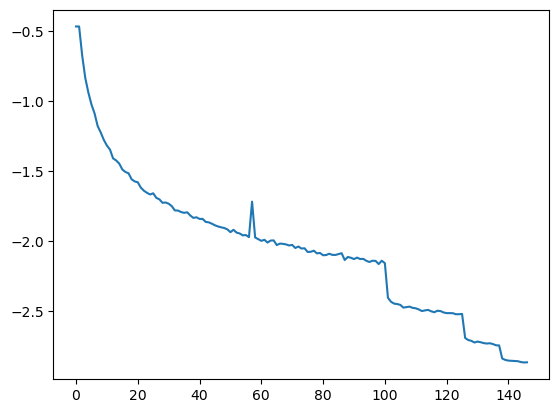

In [15]:
plt.plot(train_losses_pure, label='Pure Training')

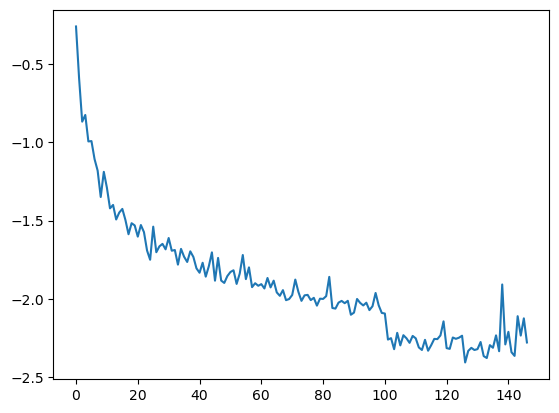

In [13]:
plt.plot(val_losses_pure, label='Pure Validation')